---

# PROJECT 1: - ANALYZING THE GLOBAL COFFE MARKET -

---

<br><br>

>---
>
>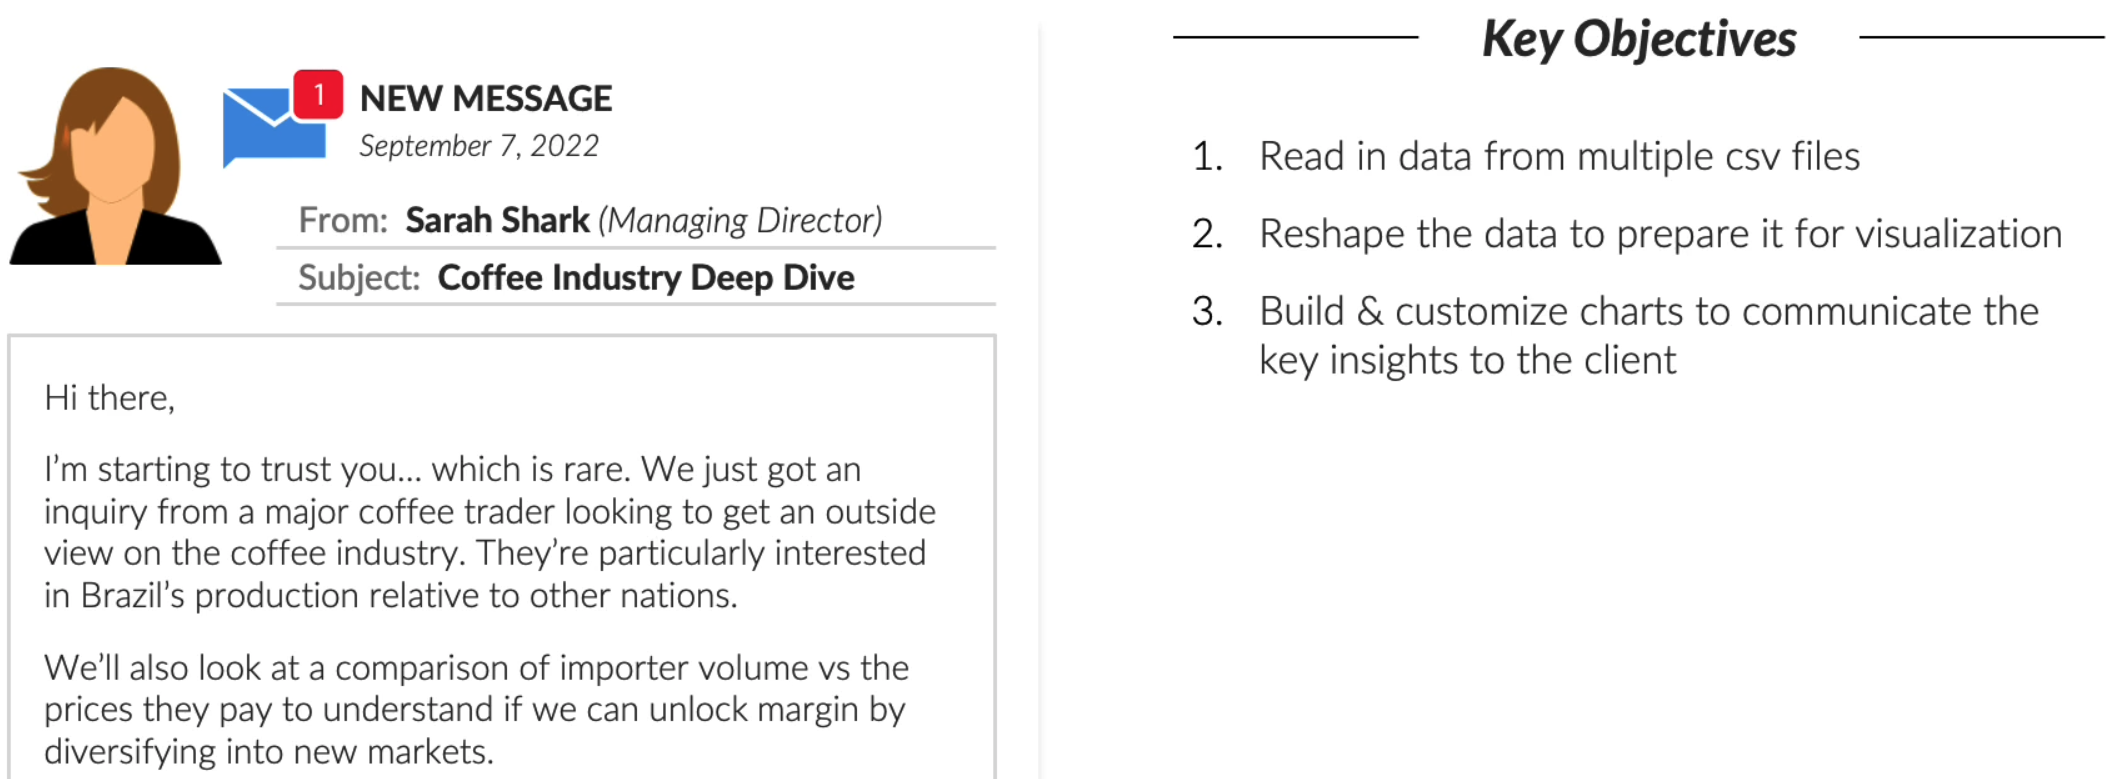
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# DataFrame 1 - Coffee Production
production = pd.read_csv('../Data/total-production.csv', index_col='total_production')
production.head(3)

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
total_production,,,,,,,,,,,,,,,,,,,,,
Angola,50.3450,79.3310,77.5200,32.6080,76.802,62.1090,70.925,64.330,85.3440,54.9390,...,13.4200,34.9700,28.7150,32.7900,34.9350,39.4050,40.5150,44.8300,35.0060,40.3874
Bolivia (Plurinational State of),122.7770,103.5360,120.2350,50.8230,116.944,142.4850,124.579,140.719,137.9850,157.7020,...,128.4751,117.2249,131.8354,105.2812,119.9122,99.8766,84.2191,77.9835,83.8112,82.5687
Brazil,27285.6286,27293.4934,34603.3542,28166.9786,28192.047,18060.2022,29196.743,26148.004,36760.8533,47577.8065,...,43976.8120,55428.4102,48591.8289,55418.0012,54688.9664,53304.7669,52870.5876,56788.1784,52739.8635,62924.8836


<br><br>

---

## Top 10 Coffee Production - Over Time

In [3]:
df_prod = production.apply(lambda x: sum(x), axis=1).sort_values(ascending=False).round().iloc[:10]
df_prod

total_production
Brazil       1190966.0
Viet Nam      439541.0
Colombia      345871.0
Indonesia     245117.0
Ethiopia      141543.0
India         132026.0
Mexico        126908.0
Guatemala     113401.0
Honduras      105457.0
Uganda         93146.0
dtype: float64

<br><br>

---



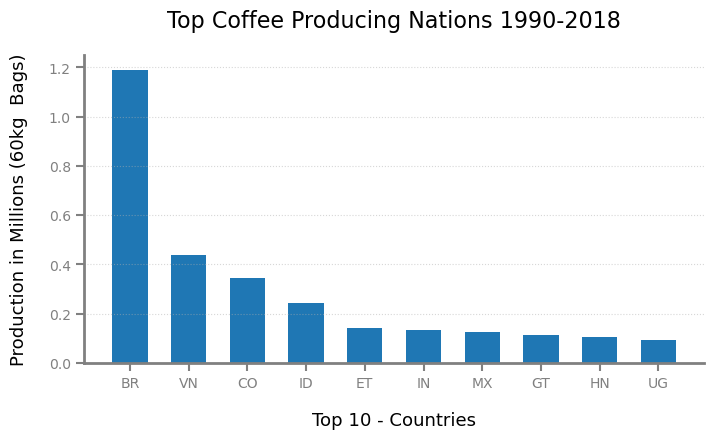

In [4]:
x_names = ['BR', 'VN', 'CO', 'ID', 'ET', 'IN', 'MX', 'GT', 'HN', 'UG']

# --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x=x_names, height=df_prod/1e6, width=0.6)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')
ax.spines[['left', 'bottom']].set_linewidth(2)
ax.spines[['left', 'bottom']].set_linestyle('-')
ax.tick_params(axis='both', direction='out', length=6, width=1.5,
               color='gray', colors='gray')


ax.set_title('Top Coffee Producing Nations 1990-2018', fontsize=16, pad=20)
ax.set_xlabel('Top 10 - Countries', fontsize=13, labelpad=15)
ax.set_ylabel('Production in Millions (60kg  Bags)', fontsize=13, labelpad=15)

ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.show()

<br><br>

---

## Top 5 Coffee Production - Over Time


In [5]:
production.head(3)

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
total_production,,,,,,,,,,,,,,,,,,,,,
Angola,50.3450,79.3310,77.5200,32.6080,76.802,62.1090,70.925,64.330,85.3440,54.9390,...,13.4200,34.9700,28.7150,32.7900,34.9350,39.4050,40.5150,44.8300,35.0060,40.3874
Bolivia (Plurinational State of),122.7770,103.5360,120.2350,50.8230,116.944,142.4850,124.579,140.719,137.9850,157.7020,...,128.4751,117.2249,131.8354,105.2812,119.9122,99.8766,84.2191,77.9835,83.8112,82.5687
Brazil,27285.6286,27293.4934,34603.3542,28166.9786,28192.047,18060.2022,29196.743,26148.004,36760.8533,47577.8065,...,43976.8120,55428.4102,48591.8289,55418.0012,54688.9664,53304.7669,52870.5876,56788.1784,52739.8635,62924.8836


In [6]:
top_prod = ['Brazil', 'Viet Nam', 'Colombia', 'Indonesia', 'Ethiopia']
df_prod2 = production.loc[top_prod, :].T # Selecting Rows and then Transpose
df_prod2.head()

total_production,Brazil,Viet Nam,Colombia,Indonesia,Ethiopia
1990,27285.6286,1310.288,14396.000,7441.383,2909.451
1991,27293.4934,1437.848,17980.397,8493.196,2924.664
1992,34603.3542,2340.447,14946.878,5569.478,1825.171
1993,28166.9786,3020.216,11422.422,6743.288,2967.004
1994,28192.0470,3631.609,12964.000,5367.878,2762.730


In [7]:
# Set index as 'datetime64[ns]' data type...
df_prod2.index = pd.to_datetime(df_prod2.index)
df_prod2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 29 entries, 1990-01-01 to 2018-01-01
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brazil     29 non-null     float64
 1   Viet Nam   29 non-null     float64
 2   Colombia   29 non-null     float64
 3   Indonesia  29 non-null     float64
 4   Ethiopia   29 non-null     float64
dtypes: float64(5)
memory usage: 1.4 KB


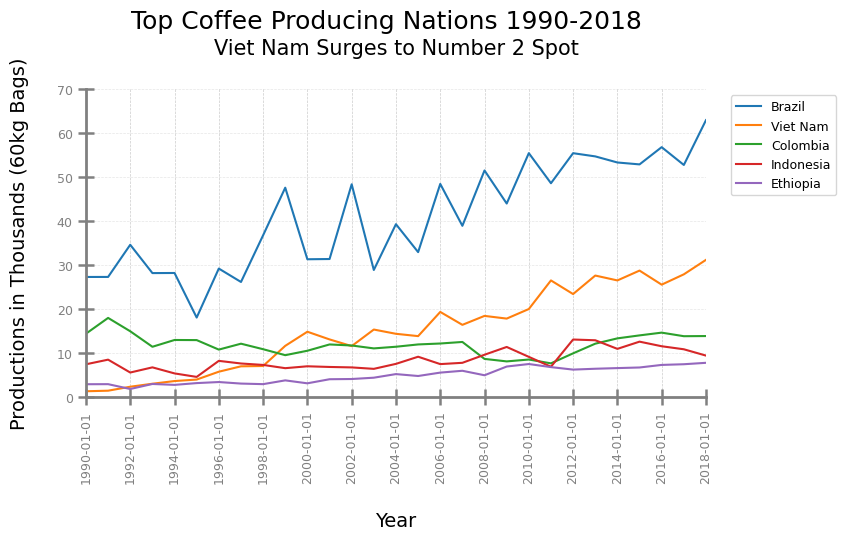

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_prod2.index, df_prod2/1e3)
ax.set_xlim(pd.Timestamp('1990-01-01'), pd.Timestamp('2018-01-01'))
ax.set_xticks(df_prod2.index[::2])
ax.set_ylim(0, 70)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')
ax.spines[['left', 'bottom']].set_linewidth(2)
ax.tick_params(axis='y', direction='inout', length=12, width=1.8,
               color='gray', colors='gray', labelsize=9)
ax.tick_params(axis='x', direction='inout', length=12, width=1.8,
               color='gray', colors='gray', labelsize=9, labelrotation=90)
# plt.setp(ax.get_xticklabels(), rotation=90, ha='center')

fig.suptitle('Top Coffee Producing Nations 1990-2018', fontsize=18, y=1.08)
ax.set_title('Viet Nam Surges to Number 2 Spot', fontsize=15, pad=25)
ax.set_xlabel('Year', fontsize=14, labelpad=20)
ax.set_ylabel('Productions in Thousands (60kg Bags)', fontsize=14, labelpad=20)

ax.legend(df_prod2.columns, bbox_to_anchor=(1.03, 1), fontsize=9)
ax.grid(axis='y', ls='--', lw=0.5, color='gray', alpha=0.2)
ax.grid(axis='x', ls='--', lw=0.5, color='gray', alpha=0.4)

plt.show()

<br><br>

---

## Composition Over Time

In [9]:
production.T.head(2)

total_production,Angola,Bolivia (Plurinational State of),Brazil,Burundi,Ecuador,Indonesia,Madagascar,Malawi,Papua New Guinea,Paraguay,...,Panama,Sierra Leone,Sri Lanka,Thailand,Togo,Trinidad & Tobago,Uganda,Venezuela,Viet Nam,Yemen
1990,50.345,122.777,27285.6286,487.393,1503.815,7441.383,982.447,104.628,962.841,130.627,...,214.987,42.783,95.870,757.017,161.308,14.581,1955.009,1122.477,1310.288,0.0
1991,79.331,103.536,27293.4934,667.199,2123.824,8493.196,932.513,124.286,746.816,79.653,...,192.532,54.379,81.549,1468.936,432.652,17.792,2088.001,940.704,1437.848,0.0


In [10]:
prod_brazil = production.T[['Brazil']]
prod_brazil.head(3)

total_production,Brazil
1990,27285.6286
1991,27293.4934
1992,34603.3542


In [11]:
prod_world = production.T.drop(labels=['Brazil'], axis=1)

prod_world['World'] = prod_world.apply(lambda x: sum(x), axis=1)
prod_world = prod_world[['World']]
prod_world.head(3)

total_production,World
1990,65944.431
1991,73973.191
1992,63922.545


In [12]:
brazil_vs_others = pd.concat([prod_brazil, prod_world], axis=1, join='inner')
brazil_vs_others.head(3)

total_production,Brazil,World
1990,27285.6286,65944.431
1991,27293.4934,73973.191
1992,34603.3542,63922.545


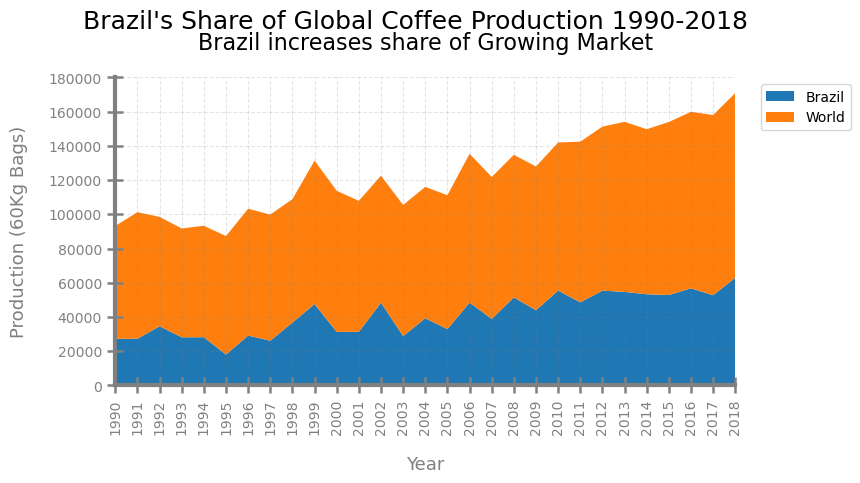

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.stackplot(brazil_vs_others.index,
             brazil_vs_others['Brazil'],
             brazil_vs_others['World'])
ax.set_xlim('1990', '2018')
ax.set_ylim(0, 180000)

ax.tick_params(axis='x', direction='inout', length=12, width=1.8,
               color='gray', colors='gray', labelsize=10, labelrotation=90,)
ax.tick_params(axis='y', direction='inout', length=12, width=1.8,
               color='gray', colors='gray', labelsize=10)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')
ax.spines[['left', 'bottom']].set_linewidth(3)

fig.suptitle("Brazil's Share of Global Coffee Production 1990-2018", fontsize=18, y=1.05)
ax.set_title('Brazil increases share of Growing Market', fontsize=16, pad=20)
ax.set_xlabel('Year', fontsize=13, labelpad=15, color='gray')
ax.set_ylabel('Production (60Kg Bags)', fontsize=13, labelpad=15, color='gray')

ax.grid(axis='both', ls='--', color='gray', alpha=0.2)
ax.legend(brazil_vs_others.columns,
          bbox_to_anchor=(1.03, 1), fontsize=10)
plt.show()

<br><br>

---

## Production Relationships

In [14]:
production.head(2)

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
total_production,,,,,,,,,,,,,,,,,,,,,
Angola,50.345,79.331,77.520,32.608,76.802,62.109,70.925,64.330,85.344,54.939,...,13.4200,34.9700,28.7150,32.7900,34.9350,39.4050,40.5150,44.8300,35.0060,40.3874
Bolivia (Plurinational State of),122.777,103.536,120.235,50.823,116.944,142.485,124.579,140.719,137.985,157.702,...,128.4751,117.2249,131.8354,105.2812,119.9122,99.8766,84.2191,77.9835,83.8112,82.5687


In [15]:
countries = ['Brazil', 'Viet Nam', 'Venezuela']
df_relation = production.loc[countries, :].T
df_relation.head(3)

total_production,Brazil,Viet Nam,Venezuela
1990,27285.6286,1310.288,1122.477
1991,27293.4934,1437.848,940.704
1992,34603.3542,2340.447,1215.298


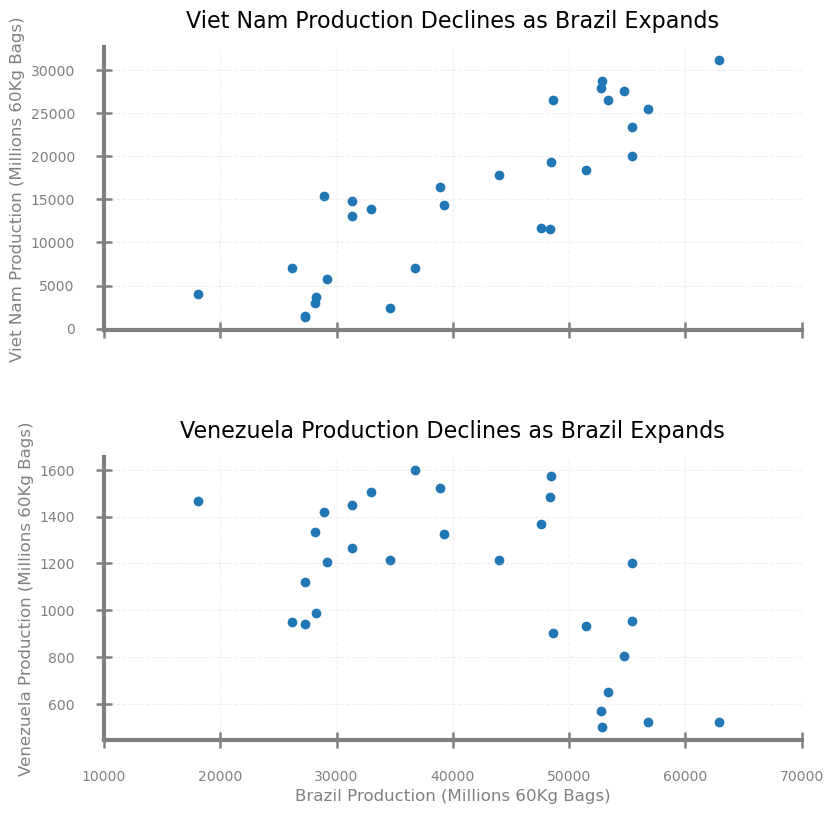

In [16]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9, 9))#, constrained_layout=True) # Option 2: to separate plots
# Option 3: to separate plots
fig.subplots_adjust(hspace=0.45)

for n in range(1,3):
    ax[n-1].scatter(x=df_relation['Brazil'], y=df_relation.iloc[:, n])
   
    ax[n-1].spines[['top', 'right']].set_visible(False)
    ax[n-1].spines[['bottom', 'left']].set_color('gray')
    ax[n-1].spines[['bottom', 'left']].set_linewidth(3)
    ax[n-1].tick_params(axis='both', direction='inout', length=12, width=1.8,
                        color='gray', colors='gray', pad=15)
    ax[n-1].grid(axis='both', ls='--', alpha=0.2)
    ax[n-1].set_xlim(10000, 70000)
    
    ax[n-1].set_title(f'{df_relation.columns[n]} Production Declines as Brazil Expands', 
                      fontsize=16, y=1.04)
    ax[n-1].set_ylabel(f'{df_relation.columns[n]} Production (Millions 60Kg Bags)',
                       fontsize=12, color='gray')

ax[1].set_xlabel('Brazil Production (Millions 60Kg Bags)', fontsize=12, c='gray')



# plt.tight_layout() # Option 1: to separate plots
plt.show()

<br><br>

---

## Composition of Coffee Production

In [17]:
production.head(2)

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
total_production,,,,,,,,,,,,,,,,,,,,,
Angola,50.345,79.331,77.520,32.608,76.802,62.109,70.925,64.330,85.344,54.939,...,13.4200,34.9700,28.7150,32.7900,34.9350,39.4050,40.5150,44.8300,35.0060,40.3874
Bolivia (Plurinational State of),122.777,103.536,120.235,50.823,116.944,142.485,124.579,140.719,137.985,157.702,...,128.4751,117.2249,131.8354,105.2812,119.9122,99.8766,84.2191,77.9835,83.8112,82.5687


In [18]:
df_1990 = production.loc[:, ['1990']].sort_values(by=['1990'], ascending=False)
df_1990_top = df_1990.iloc[:5]
df_1990_rest = df_1990.iloc[5:]
df_1990_top

,1990
total_production,
Brazil,27285.6286
Colombia,14396.0000
Indonesia,7441.3830
Mexico,4674.2450
Guatemala,3270.5290


In [19]:
rest_1990 = pd.DataFrame({'Rest_of_World':df_1990_rest.sum()}).T

# df_1990_top.loc['rest_of_world', rest_1990]
rest_1990

,1990
Rest_of_World,36162.274


In [20]:
df_final_1990 = pd.concat([df_1990_top, rest_1990], axis=0, join='inner').sort_values(by='1990', ascending=False)
df_final_1990

,1990
Rest_of_World,36162.2740
Brazil,27285.6286
Colombia,14396.0000
Indonesia,7441.3830
Mexico,4674.2450
Guatemala,3270.5290


---

In [21]:
df_2018 = production.loc[:, ['2018']].sort_values(by='2018', ascending=False)
df_2018_top = df_2018.iloc[:5]
df_2018_rest = df_2018.iloc[5:]
df_2018_top

,2018
total_production,
Brazil,62924.8836
Viet Nam,31174.0742
Colombia,13857.9620
Indonesia,9417.5942
Ethiopia,7776.2234


In [22]:
rest_2018 = pd.DataFrame({'Rest_of_World':df_2018_rest.sum()}).T
rest_2018

,2018
Rest_of_World,45786.0003


In [23]:
df_final_2018 = pd.concat([df_2018_top, rest_2018], axis=0, join='inner').sort_values(by='2018', ascending=False)
df_final_2018

,2018
Brazil,62924.8836
Rest_of_World,45786.0003
Viet Nam,31174.0742
Colombia,13857.9620
Indonesia,9417.5942
Ethiopia,7776.2234


<br>

---

### Time to plot the Pie Charts

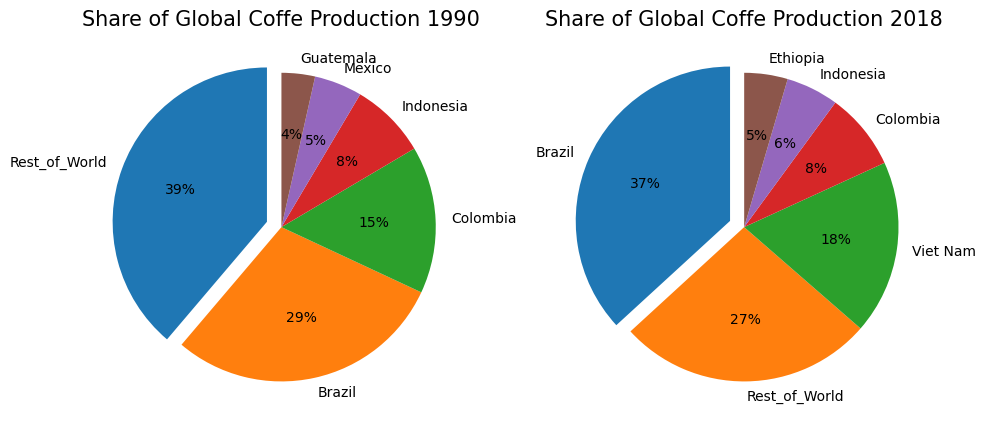

In [24]:
year = [1990, 2018]
dfs = [df_final_1990, df_final_2018]

fig, axes = plt.subplots(figsize=(10, 9), ncols=2)

for ax, yr, df in zip(axes, year, dfs):
    ax.pie(x=df.iloc[:, 0], startangle=90,
           labels=df.index, autopct='%.0f%%',
           explode=[0.1]+[0]*(len(df)-1))
    
    ax.set_title(f'Share of Global Coffe Production {yr}',
                    fontsize=15)

plt.tight_layout()
plt.show()

<br><br>

---

### Time to Plot Performace or Semi-Donnut Charts

In [25]:
df_final_1990

,1990
Rest_of_World,36162.2740
Brazil,27285.6286
Colombia,14396.0000
Indonesia,7441.3830
Mexico,4674.2450
Guatemala,3270.5290


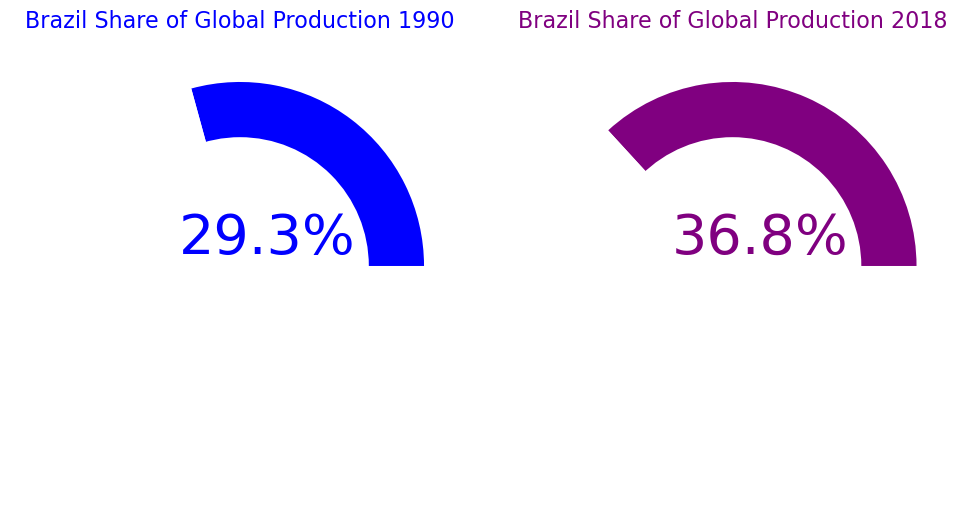

In [26]:
c_perform = ['blue', 'purple']

fig, axes = plt.subplots(figsize=(10, 5), ncols=2)

for ax, yr, df, c in zip(axes, year, dfs, c_perform):
    lst_total = (list(df.loc['Brazil']) + 
                 list(df.drop('Brazil', axis=0).sum()))
    ax.pie(lst_total, radius=1,
           startangle=0, counterclock=True,
           colors=[c]+['white']*(len(df) - 1))
    # -------------------------------------------------
    ax.add_artist(plt.Circle((0, 0), 0.7, fc='white'))
    # -------------------------------------------------
    col = df.iloc[:, 0]
    value = 100*col.loc['Brazil']/col.sum()
    
    ax.text(x=0.15, y=0.15, s=f'{value:.1f}%',
            ha='center', va='center', fontsize=40,
            c=c)
    # -------------------------------------------------
    ax.set_title(f'Brazil Share of Global Production {yr}',
                 fontsize=16, color=c)

plt.tight_layout()
plt.show()

<br><br>

---

## Price and Imports

In [27]:
# DataFrame 2 - Coffee Importation
imports = pd.read_csv('../Data/imports.csv', index_col='imports').fillna(0)
imports.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
imports,,,,,,,,,,,,,,,,,,,,,
Austria,1880.0,2058.0,2206.0,1836.0,1417.0,1231.0,1210.0,1294.0,1293.0,1500.0,...,1309.0,1369.0,1452.0,1559.0,1555.0,0.0,0.0,0.0,0.0,0.0
Belgium,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3003.0,...,5916.0,5924.0,5828.0,5668.0,5502.0,0.0,0.0,0.0,0.0,0.0
Belgium/Luxembourg,2015.0,1746.0,1828.0,2063.0,2262.0,2401.0,2526.0,2544.0,3580.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bulgaria,268.0,200.0,182.0,397.0,463.0,515.0,272.0,294.0,342.0,367.0,...,523.0,528.0,482.0,560.0,609.0,0.0,0.0,0.0,0.0,0.0
Croatia,0.0,0.0,168.0,163.0,193.0,320.0,322.0,385.0,339.0,352.0,...,394.0,394.0,391.0,384.0,413.0,0.0,0.0,0.0,0.0,0.0


In [28]:
df_imports = imports.apply(lambda x: sum(x)/len(x), axis=1).to_frame().sort_values(0, ascending=False)
df_imports.columns=['Avg_Imports']
df_imports

,Avg_Imports
imports,
USA,23365.761845
Germany,13537.379310
Asia & Oceania,9986.409021
Japan,6862.275235
Italy,5542.310345
...,...
Virgin Islands (UK),0.279826
Comoros,0.269322
Cook Islands,0.254586


In [29]:
# DataFrame 3 - Coffee Prices
prices = pd.read_csv('../Data/retail-prices.csv', index_col='retail_prices')
prices.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
retail_prices,,,,,,,,,,,,,,,,,,,,,
Austria,10.816777,10.088300,11.015453,10.971302,10.110375,11.434879,11.964680,9.646799,8.763797,7.240618,...,15.342163,14.768212,18.366446,18.498896,19.028698,19.050773,16.423841,12.450331,13.730684,14.635762
Cyprus,6.247241,6.181015,6.335541,5.739514,7.019868,9.403974,9.116998,8.918322,10.176600,9.690949,...,12.207506,11.501104,13.377483,14.039735,14.282561,14.304636,11.699779,11.699779,12.141280,12.781457
Denmark,8.410596,8.101545,8.366446,7.682119,9.823400,12.295806,10.618102,10.949227,10.860927,8.675497,...,11.677704,12.008830,15.275938,14.834437,14.039735,14.194260,12.913907,10.905077,11.103753,11.699779
Finland,6.578366,6.004415,5.430464,4.282561,6.026490,8.763797,7.108168,7.726269,7.549669,5.739514,...,7.748344,8.145695,11.832230,10.596026,9.470199,9.514349,8.609272,8.101545,9.050773,9.359823
France,8.233996,7.571744,5.099338,4.481236,5.298013,8.145695,7.284768,6.092715,6.136865,5.629139,...,8.366446,7.991170,9.116998,8.653422,8.653422,8.322296,6.865342,7.196468,7.505519,8.123620


In [30]:
df_prices = prices.apply(lambda x: sum(x)/len(x), axis=1).fillna(0).to_frame().sort_values(by=0, ascending=False)
df_prices.columns = ['Avg_Prices']
df_prices

,Avg_Prices
retail_prices,
United Kingdom,32.939027
Japan,21.472939
Italy,14.199589
Austria,11.571135
Portugal,10.921063
Denmark,10.494025
Cyprus,10.437695
Germany,9.515110
Norway,9.409302


In [31]:
df_all = (pd
    .merge(df_imports, df_prices, left_on=df_imports.index,
           right_on=df_prices.index, how='inner')
    .sort_values(by='Avg_Imports', ascending=False)
    .rename(columns={'key_0':'Country'})
)
print(list(df_all.Country), '\n')

df_all.head(3)

['   Germany', 'Japan', '   Italy', '   France', '   Spain', '   Netherlands', '   Sweden', '   Austria', '   Finland', '   Denmark', 'Norway', '   Portugal', '   Cyprus'] 



,Country,Avg_Imports,Avg_Prices
0,Germany,13537.379310,9.515110
1,Japan,6862.275235,21.472939
2,Italy,5542.310345,14.199589


In [32]:
df_all['Country'] = df_all['Country'].str.strip(' ')

print(list(df_all.Country), '\n')
df_all

['Germany', 'Japan', 'Italy', 'France', 'Spain', 'Netherlands', 'Sweden', 'Austria', 'Finland', 'Denmark', 'Norway', 'Portugal', 'Cyprus'] 



,Country,Avg_Imports,Avg_Prices
0,Germany,13537.379310,9.515110
1,Japan,6862.275235,21.472939
2,Italy,5542.310345,14.199589
3,France,5389.620690,6.850879
4,Spain,3348.655172,8.029992
5,Netherlands,2423.275862,8.931263
6,Sweden,1341.206897,8.054350
7,Austria,1283.655172,11.571135
8,Finland,957.965517,7.211692
9,Denmark,820.793103,10.494025


<br><br>

---

### Lets plot the bars

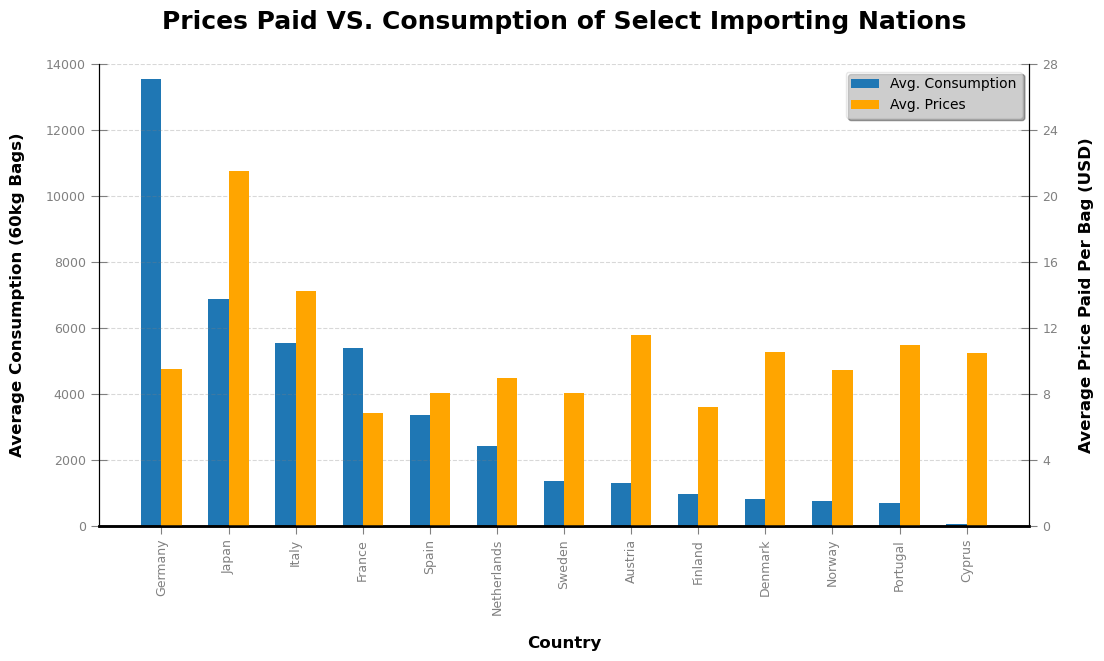

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_all.index))
width = 0.3

ax.bar(x - width/2, height=df_all.Avg_Imports, 
       label='Avg. Consumption', width=width)
ax.set_title('Prices Paid VS. Consumption of Select Importing Nations', 
             fontsize=18, fontweight='bold', pad=25)
# --------------------------------------
ax.set_ylim(0, 14000)
ax.tick_params(axis='x', color='gray', colors='gray', labelsize=9, 
               direction='inout', length=12, labelrotation=90)
ax.tick_params(axis='y', color='gray', colors='gray', labelsize=9,
               direction='inout', length=12)
ax.spines[['top']].set_visible(False)
ax.spines[['bottom']].set_linewidth(1.8)
ax.grid(axis='y', ls='--', color='gray', alpha=0.3)
# --------------------------------------
ax.set_ylabel('Average Consumption (60kg Bags)', fontsize=12, fontweight='bold', labelpad=15)
ax.set_xlabel('Country', fontsize=12, fontweight='bold', labelpad=15)
# ----------------------------------------------------------------------------
ax2 = ax.twinx()
ax2.bar(x + width/2, height=df_all.Avg_Prices, 
       label='Avg. Prices', width=width, color='orange')
# --------------------------------------
ax2.set_ylim(0,28)
ax2.set_xticks(x)
ax2.set_xticklabels(df_all.Country)
ax2.set_yticks(list(range(0, 29, 4)))
ax2.tick_params(axis='y', color='gray', colors='gray', labelsize=9,
                direction='inout', length=12)
ax2.spines[['top']].set_visible(False)
ax2.spines[['bottom']].set_linewidth(1.8)
# --------------------------------------
ax2.set_ylabel('Average Price Paid Per Bag (USD)', fontsize=12, fontweight='bold', labelpad=15)
ax2.set_xlabel('Country', fontsize=12, fontweight='bold', labelpad=15)

fig.legend(bbox_to_anchor=(0.9, 0.878), shadow=True, 
           frameon=True, fancybox=True, framealpha=0.45)
plt.show()